# Thinning Sensitivity Analysis (2km, 5km, 10km)

Checks whether richness conclusions are robust to grid size choice.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='paper')
RANDOM_SEED = 42
GRID_LIST = [2.0, 5.0, 10.0]


In [2]:
p = next((x for x in [Path('file6.csv'), Path('../file6.csv'), Path('../../file6.csv')] if x.exists()), None)
if p is None:
    raise FileNotFoundError('file6.csv not found')
cols = ['stateProvince','verbatimScientificName','decimalLatitude','decimalLongitude','eventDate']
df = pd.read_csv(p, usecols=cols, low_memory=False).dropna(subset=cols)
for c in ['decimalLatitude','decimalLongitude']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['decimalLatitude','decimalLongitude'])
lon0 = float(df['decimalLongitude'].median())
lat0 = float(df['decimalLatitude'].median())
lat_rad = np.radians(df['decimalLatitude'].to_numpy())
df['x_km'] = (df['decimalLongitude'].to_numpy() - lon0) * 111.320 * np.cos(lat_rad)
df['y_km'] = (df['decimalLatitude'].to_numpy() - lat0) * 110.574


In [3]:
rows=[]
for g in GRID_LIST:
    work = df.copy()
    work['grid_x'] = np.floor(work['x_km']/g).astype(int)
    work['grid_y'] = np.floor(work['y_km']/g).astype(int)
    work['cell_id'] = work['stateProvince'].astype(str) + '|' + work['grid_x'].astype(str) + '_' + work['grid_y'].astype(str)
    work['_key'] = work['cell_id'] + '|' + work['verbatimScientificName']
    rng = np.random.default_rng(RANDOM_SEED)
    work['_r'] = rng.random(len(work))
    thin = work.sort_values('_r').groupby('_key', as_index=False).head(1)
    district = thin.groupby('stateProvince', as_index=False).agg(mean_cell_richness=('verbatimScientificName','nunique'))
    rows.append({'grid_km':g,'retained_rows':len(thin),'n_cells':thin['cell_id'].nunique(),'overall_richness':thin['verbatimScientificName'].nunique(),'district_mean_of_richness':district['mean_cell_richness'].mean()})
summary = pd.DataFrame(rows)
summary


,grid_km,retained_rows,n_cells,overall_richness,district_mean_of_richness
0,2.0,156196,4206,429,243.64
1,5.0,95608,1740,429,243.64
2,10.0,58799,739,429,243.64


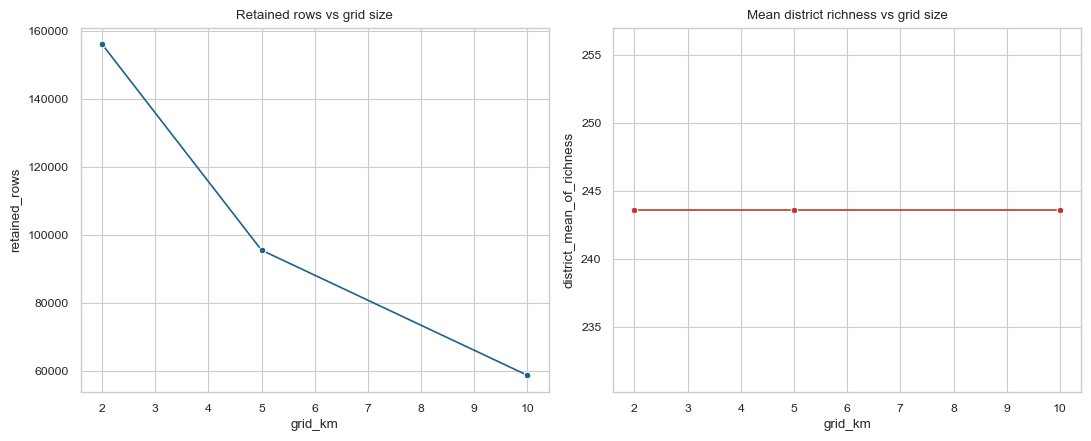

In [4]:
fig, axes = plt.subplots(1,2, figsize=(11,4.5))
sns.lineplot(data=summary, x='grid_km', y='retained_rows', marker='o', ax=axes[0], color='#1f618d')
axes[0].set_title('Retained rows vs grid size')
sns.lineplot(data=summary, x='grid_km', y='district_mean_of_richness', marker='o', ax=axes[1], color='#c0392b')
axes[1].set_title('Mean district richness vs grid size')
plt.tight_layout()
plt.show()
